# Chapter 21 - Monte Carlo Methods

## Monte Carlo Methods in Radiation Transport

- Monte Carlo methods give us a way to simulate the behavior of radiation without having to resort to discretized differential equations.

- Using sampling and tracking of individual simulated neutrons, we can solve shielding problems using realistic materials.

- Rejection sampling is a technique for drawing random numbers from a distribution when the cumulative density function (CDF) is not known.


## 21.1 Analog Physics

In this chapter we will use Python to create synthetic neutrons. We will then follow these
neutrons to see what will happen in a system. The process of using simulated, synthetic particles that behave in a similar manner as actual neutrons (or other particles) is an example
of analog physics. This gives a retro-sounding ring to the process, like it is something that
goes along with vinyl records and vacuum-tube amplifiers. We mean here that our synthetic
neutrons are analogs of true neutrons.

The way we will deal with these particles is using random sampling of their interactions,
just as quantum mechanics governs the behavior of particles using probabilities. This is different than what we did in diffusion methods for simulating neutron behavior: in those models
we derived differential equations for the expected behavior of a collection of neutrons. In analog physics we simulate many particles and then we compute the mean behavior (or other
quantities that interest us).

These methods are called Monte Carlo methods. The first modern Monte Carlo methods
were developed by Stanislaw Ulam during the Manhattan Project, and Nicholas Metropolis coined the name after a famous casino. One benefit of Monte Carlo methods is that they
require much less mathematics in the algorithms. Once we know how to draw random numbers appropriately, we just need to “roll dice” many, many times to get the answer.

## 21.2 Probability Preliminaries

We will need to know a few things about probabilities before we begin. A cumulative
distribution function (CDF) is defined as a function $F(x)$ that is the probability that a random
variable $c$, from a particular distribution, is less than $x$. In mathematical form we write this as

$$
F(x) = P(c < x).
$$

Because probabilities are always in the range $[0,1]$, the function $F(x) \in [0,1]$. As an example,
consider the random variable defined by the value of a roll of a single die. In this case, the
CDF is given by

$$
F(x)=
\left\{
\begin{array}{ll}
0 & x \le 1 \\
\frac{1}{6} & 1 < x \le 2 \\
\frac{1}{3} & 2 < x \le 3 \\
\frac{1}{2} & 3 < x \le 4 \\
\frac{2}{3} & 4 < x \le 5 \\
\frac{5}{6} & 5 < x \le 6 \\
1 & 6 < x
\end{array}
\right.
$$

Using this definition, $F(6.1)$ is 1, because it is certain that the roll will give a number less
than 6.1.



The way that the CDF is defined leads to two important limits:

$$
\lim_{x \to \infty} F(x) = 1, \qquad
\lim_{x \to -\infty} F(x) = 0.
$$

Along with the CDF we will use the probability density function (PDF), written as $f(x)$.
The PDF is defined such that

$$
f(x)\,dx = \text{The probability that the random variable is in } dx \text{ about } x.
$$

The PDF is the derivative of the CDF and they are related by

$$
f(x) = \frac{dF}{dx},
$$

and

$$
F(x) = \int_{-\infty}^{x} f(x')\,dx'.
$$

Also, from these relations we get

$$
\int_{-\infty}^{\infty} f(x)\,dx = 1.
$$

This relation shows that probability densities are normalized to 1 and can be interpreted as
the probability of the random variable being between $-\infty$ and $\infty$ is 1.

Going back to the roll of a single die, the PDF for this random variable is the sum of Dirac
delta functions because the value of a roll can only be the integers 1–6. This PDF is

$$
f(x) = \frac{1}{6} \left[ \delta(x-1) + \delta(x-2) + \delta(x-3) + \delta(x-4) + \delta(x-5) + \delta(x-6) \right].
$$

Notice that the factor of one-sixth is required to satisfy the normalization condition.

Using the PDF we can find the expected value of some function of the random variable.
Consider the function $g(x)$, the expected value of this function, $E[g(x)]$, is defined by the integral

$$
E[g(x)] = \int_{-\infty}^{\infty} g(x) f(x)\,dx.
$$

An important expected value is the mean of the random variable. The mean is found by
determining the expected value of the function $g(x)=x$. The mean is sometimes written as $\bar{x}$
and it is defined as

$$
\bar{x} = \int_{-\infty}^{\infty} x f(x)\,dx.
$$

## 21.3 The Exponential Distribution

The most important distribution for Monte Carlo methods for neutron transport is the
exponential distribution. This is because the probability that a neutron travels a number of
mean-free paths in $d\lambda$ about $\lambda$ before having a collision is given by

$$
f(\lambda)\,d\lambda = e^{-\lambda}\, d\lambda, \qquad \text{for } \lambda > 0.
$$

This distribution tells us that if $N$ neutrons travel $\lambda$ mean-free paths without a collision, then
we expect $Ne^{-1}$ neutrons to travel $\lambda + 1$ mean-free paths. The average distance traveled by
a neutron without having a collision, in units of mean-free paths, based on this distribution
can be found via the integral

$$
\bar{\lambda} = \int_{0}^{\infty} \lambda e^{-\lambda}\, d\lambda = 1.
$$

This shows why we call $\lambda$ the mean-free path: it is the expected distance a neutron will travel
without having a collision.

Usually, we want to work in units of distance rather than mean-free paths. To convert the
exponential distribution to be a function of distance, rather than mean-free paths, we use the
total macroscopic cross-section for the material times a distance to write

$$
\Sigma_t x = \lambda, \qquad d\lambda = \Sigma_t\, dx.
$$

Making this substitution we get the PDF for the exponential distribution as

$$
f(x) = \Sigma_t e^{-\Sigma_t x}.
$$

We can check that this is a proper PDF by integrating over all $x$ and seeing that the integral
equals one:

$$
\int_{0}^{\infty} \Sigma_t e^{-\Sigma_t x}\, dx
= \left[ - e^{-\Sigma_t x} \right]_{0}^{\infty}
= 1.
$$

From this we can also define the CDF:

$$
F(x) = \int_{0}^{x} \Sigma_t e^{-\Sigma_t x'}\, dx'
= 1 - e^{-\Sigma_t x}.
$$

Below is a plot of the CDF and PDF:

<img src="Uploaded Media/21.2.png">



## 21.4 A First Monte Carlo Problem

Now we would like to use Monte Carlo solve the following problem: a beam of neutrons
strikes a 3 cm thick slab of material with $\Sigma_t = 2.0\ \text{cm}^{-1}$. What fraction of the neutrons get
through the slab without a collision? Using the results from the previous section, we know
that the answer to this problem is defined by the integral

$$
\int_{3}^{\infty} \Sigma_t e^{-\Sigma_t x}\, dx = e^{-2 \times 3} \approx 0.002478752177.
$$

We would like to solve this problem with Monte Carlo using the following procedure

1. Create neutron.  
2. Sample randomly a distance to collision from the exponential distribution.  
3. Check to see if the distance to collision is greater than 3.  
4. Go back to 1 until we’ve run “enough” neutrons.  

At the end of this procedure the ratio of the number of neutrons that went through the slab
to those that we created is the fraction that we are looking for.

The hard part is that we do not know how to generate a random sample from the exponential distribution. We do, however, know how to get a random number between 0 and 1
using NumPy’s random function or the functions from the random module. We also know
that the CDF, $F(x)$, is always between 0 and 1. Therefore, the following procedure can give
me a random number from the exponential distribution:

1. Pick a random number between 0 and 1, call it $\theta$  
2. Invert the CDF to solve for $x$ in $F(x)= \theta$; this value of $x$ is my random sample.  

In our case we need to solve for $x$ in

$$
\theta = 1 - e^{-\Sigma_t x},
$$

which gives us

$$
x = \frac{-\log(1 - \theta)}{\Sigma_t}.
$$

We can translate this algorithm to Python in a few short steps. The algorithm will require
the user to enter the number of neutrons requested, $N$, and the thickness of the slab and the
macroscopic cross-section for the material.

In [ ]:
def slab_transmission(Sig_t,thickness,N):
    """Compute the fraction of neutrons that leak through a slab
    Inputs:
        Sig_t: The total macroscopic x-section
        thickness: Width of the slab
        N: Number of neutrons to simulate
    Returns:
        transmission: The fraction of neutrons that made it through
    """
    thetas = np.random.random(N)
    x = -np.log(1-thetas)/Sig_t


    transmission = np.sum(x>thickness)/N

    
    #for a small number of neutrons we’ll output a little more
    if (N<=1000):
        plt.scatter(x,np.arange(N))
        plt.xlabel("Distance to collision")
        plt.ylabel("Neutron Number")
    return transmission

To test this function we will execute it with a small number of neutrons and look at where
the collisions take place. The function will make a graph showing where neutrons had a
collision if the number of neutrons is less than or equal to 1000. This initial run will use 1000
neutrons to test this feature.

Out of 1000 neutrons only 4 made it through.
 The fraction that made it through was 0.004


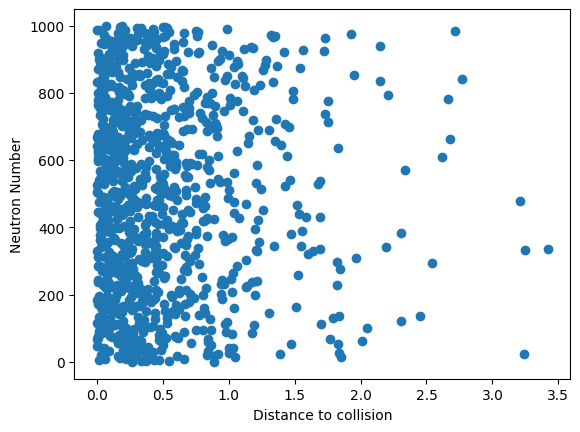

In [3]:
import numpy as np
import matplotlib.pyplot as plt
#test the functionwith a small number of neutrons
Sigma_t = 2.0
thickness = 3.0
N = 1000
transmission = slab_transmission(Sigma_t, thickness, N)
print("Out of",N,"neutrons only",int(transmission*N),
    "made it through.\n The fraction that made it through was",
    transmission)

Notice that most of the neutrons have a collision very close to the edge of the slab. Only
4 out of 1000 made it all the way through the slab (that is, only 4 had a distance to collision greater than 3). In this case we get a pretty good answer to our question (0.004 is off
by less than a factor of two), but we can check that it converges to the correct answer as

$$
N \to \infty.
$$

In [4]:
neuts = np.array([2000,4000,8000,16000,32000,
                    64000,128000,256e3,512e3,1024e3,2056e3])
for N in neuts:
    transmission = slab_transmission(Sigma_t, thickness, int(N))
    print("Out of",N,"neutrons only",int(transmission*N),
            "made it through.\n The fraction that made it through was",
            transmission)

Out of 2000.0 neutrons only 4 made it through.
 The fraction that made it through was 0.002
Out of 4000.0 neutrons only 12 made it through.
 The fraction that made it through was 0.003
Out of 8000.0 neutrons only 23 made it through.
 The fraction that made it through was 0.002875
Out of 16000.0 neutrons only 36 made it through.
 The fraction that made it through was 0.00225
Out of 32000.0 neutrons only 87 made it through.
 The fraction that made it through was 0.00271875
Out of 64000.0 neutrons only 142 made it through.
 The fraction that made it through was 0.00221875
Out of 128000.0 neutrons only 321 made it through.
 The fraction that made it through was 0.0025078125
Out of 256000.0 neutrons only 635 made it through.
 The fraction that made it through was 0.00248046875
Out of 512000.0 neutrons only 1267 made it through.
 The fraction that made it through was 0.002474609375
Out of 1024000.0 neutrons only 2545 made it through.
 The fraction that made it through was 0.0024853515625
Out

We need about 1 million simulated neutrons to get to two digits of the correct answer. Also, if we ran this again we would get different answers because we are using
random numbers. The run-to-run variability in the answers is often quantified using the
standard deviation. This variability can be thought of as the error in the Monte Carlo calculation. Practitioners often call this variability noise. The error will go down slowly because the way that Monte Carlo works. The standard deviation of the estimate when we
look at the run-to-run variability will decrease at a rate proportional to

$$
\frac{1}{\sqrt{N}}.
$$

This means that to cut the error in half we need to quadruple the number of neutrons. Another way
to think about it is to say that Monte Carlo methods are one-half order accurate. The

$$
\frac{1}{\sqrt{N}}
$$

convergence is valid for large values of $N$ and is a result of the central limit theorem.

## Recap

### CDF and PDF
A cumulative distribution function (CDF) is defined as a function $F(x)$ that is the probability that a random
variable $c$, from a particular distribution, is less than $x$. In mathematical form we write this as

$$
F(x) = P(c < x).
$$

Along with the CDF we will use the probability density function (PDF), written as $f(x)$.
The PDF is defined such that

$$
f(x)\,dx = \text{The probability that the random variable is in } dx \text{ about } x.
$$

### Exponential distribution

The most important distribution for Monte Carlo methods for neutron transport is the
exponential distribution. This is because the probability that a neutron travels a number of
mean-free paths in $d\lambda$ about $\lambda$ before having a collision is given by

$$
f(\lambda)\,d\lambda = e^{-\lambda}\, d\lambda, \qquad \text{for } \lambda > 0.
$$

The PDF for the exponential distribution as

$$
f(x) = \Sigma_t e^{-\Sigma_t x}.
$$

Below is a plot of the CDF and PDF:

- PDF - The probability for a neutron to travel a distance $x$ before having a collision
- CDF - The probability for a neutron to travel a distance shorter than $x$ before having a collision

<img src="Uploaded Media/21.2.png">


### A first Monte Carlo problem
A beam of neutrons strikes a 3 cm thick slab of material with $\Sigma_t = 2.0\ \text{cm}^{-1}$. What fraction of the neutrons get through the slab without a collision?

1. Create neutron.  
2. <u> Sample randomly a distance to collision from the exponential distribution. </u>  
3. Check to see if the distance to collision is greater than 3.  
4. Go back to 1 until we’ve run “enough” neutrons. 

#### Sample from a distribution, knowing the CDF
1. Pick a random number between 0 and 1, call it $\theta$  
2. Invert the CDF to solve for $x$ in $F(x)= \theta$; this value of $x$ is my random sample.  

In our case we need to solve for $x$ in

$$
\theta = 1 - e^{-\Sigma_t x},
$$

which gives us

$$
x = \frac{-\log(1 - \theta)}{\Sigma_t}.
$$






In [4]:
import numpy as np

def slab_transmission(Sig_t,thickness,N):
    """Compute the fraction of neutrons that leak through a slab
    Inputs:
        Sig_t: The total macroscopic x-section
        thickness: Width of the slab
        N: Number of neutrons to simulate
    Returns:
        transmission: The fraction of neutrons that made it through
    """
    thetas = np.random.random(N)
    x = -np.log(1-thetas)/Sig_t


    transmission = np.sum(x>thickness)/N

    
    #for a small number of neutrons we’ll output a little more
    if (N<=1000):
        plt.scatter(x,np.arange(N))
        plt.xlabel("Distance to collision")
        plt.ylabel("Neutron Number")
    return transmission

In [5]:
neuts = np.array([2000,4000,8000,16000,32000,
                    64000,128000,256e3,512e3,1024e3,2056e3])
for N in neuts:
    transmission = slab_transmission(Sigma_t, thickness, int(N))
    print("Out of",N,"neutrons only",int(transmission*N),
            "made it through.\n The fraction that made it through was",
            transmission)

Out of 2000.0 neutrons only 3 made it through.
 The fraction that made it through was 0.0015
Out of 4000.0 neutrons only 11 made it through.
 The fraction that made it through was 0.00275
Out of 8000.0 neutrons only 24 made it through.
 The fraction that made it through was 0.003
Out of 16000.0 neutrons only 43 made it through.
 The fraction that made it through was 0.0026875
Out of 32000.0 neutrons only 76 made it through.
 The fraction that made it through was 0.002375
Out of 64000.0 neutrons only 163 made it through.
 The fraction that made it through was 0.002546875
Out of 128000.0 neutrons only 314 made it through.
 The fraction that made it through was 0.002453125
Out of 256000.0 neutrons only 674 made it through.
 The fraction that made it through was 0.0026328125
Out of 512000.0 neutrons only 1262 made it through.
 The fraction that made it through was 0.00246484375
Out of 1024000.0 neutrons only 2587 made it through.
 The fraction that made it through was 0.0025263671875
Out o

We need about 1 million simulated neutrons to get to two digits of the correct answer. Also, if we ran this again we would get different answers because we are using
random numbers. The run-to-run variability in the answers is often quantified using the
standard deviation. This variability can be thought of as the error in the Monte Carlo calculation. Practitioners often call this variability noise. The error will go down slowly because the way that Monte Carlo works. The standard deviation of the estimate when we
look at the run-to-run variability will decrease at a rate proportional to

$$
\frac{1}{\sqrt{N}}.
$$

This means that to cut the error in half we need to quadruple the number of neutrons. Another way
to think about it is to say that Monte Carlo methods are one-half order accurate. The

$$
\frac{1}{\sqrt{N}}
$$

convergence is valid for large values of $N$ and is a result of the central limit theorem.

## 21.5 Isotropic Neutrons on a Slab
Even though it takes a lot of particles to make the error in Monte Carlo small, that does
not mean it is a bad method. In fact, the nice thing about Monte Carlo is that you have to
know very little about the mathematics of the system, all you have to do is be able to push
particles around and roll dice. To demonstrate this we will make our problem a little harder.


<img src="Uploaded Media/21.5.png" width="300">

Now say that the neutrons hitting the slab are not a beam but a distribution of neutrons
where a neutron’s path of flight relative to the normal direction to the slab is measured by
the angle $\phi$. We say that the distribution of neutrons in angle relative to the slab is uniform in
the cosine of the angle $\phi$, i.e., the neutrons are isotropic in the cosine of the angle. 

### Source particles

- A perfectly uniform spatial distribution where the radiation power per unit solid angle is constant

The differential solid angle becomes

$$
d\Omega = \sin\phi \, d\phi \, d\theta
$$
$$
d\Omega = d\theta \, d(\cos\phi)
$$



The angles
$\phi \in [-\pi/2,\pi/2]$ point into the slab, this means that the quantity $\cos \phi$ is uniformly distributed
between 0 and 1.



### Transport

For a neutron traveling in direction $\phi$ the slab can look thicker than 3.0 cm, because if the
neutron is traveling at a grazing angle to the slab it will have to travel through more of the
slab to get to the other side. We can express this as

$$
\text{thickness}(\phi) = \frac{3}{\cos \phi}.
$$


A quick check reveals that this gives us what we want: when $\phi = 0$ the neutron is traveling
straight through the slab and the thickness to that neutron is 3 cm. Also, when $\phi = \pm \pi/2$ the
thickness of the slab is infinite because the neutron is traveling parallel to the slab.

We can make the math easier by defining $\mu = \cos \phi$ and noticing that $\mu \in [0,1]$. 

### Modified procedure

To handle our more complicated problem we make a small change to our Monte Carlo method to have
each neutron have its own angle of flight relative to the slab.

1. Create neutron with $\mu$ sampled from the uniform distribution $\mu \in [0,1]$.  
2. Sample randomly a distance to collision from the exponential distribution.  
3. Check to see if the distance to collision is greater than $3/\mu$.  
4. Go back to 1 until we have run “enough” neutrons.  

The only change is that now we pick $\mu$ uniformly between 0 and 1 (recall that each value
of the cosine of the angle was equally likely. That is why this is a random distribution). Furthermore, we check to see if the distance to collision is greater than $3/\mu$. Those are the only
changes.

### Analytical solution

The solution to this problem is more complicated to find mathematically, but the answer is
expressed by the exponential integral function:

$$
\text{transmission} = \int_{0}^{1} e^{-\Sigma_t x / \mu}\, d\mu.
$$

For our case of $x = 3.0$ and $\Sigma_t = 2$ we get

$$
E_2(6) \approx 0.000318257.
$$

$E_2$ here is the exponential integral of order 2

Notice how the transmission went down (from 0.002478752177) because most particles will not have $\mu = 1$.

We can simply modify our function above to handle this case. We do this by modifying
the previous function to take as an input parameter whether the neutrons are isotropic in the
cosine of the incident angle.


In [ ]:
def slab_transmission(Sig_t,thickness,N,isotropic=False):
    """Compute the fraction of neutrons that leak through a slab
    Inputs:
        Sig_t: The total macroscopic x-section
        thickness: Width of the slab
        N: Number of neutrons to simulate
        isotropic: Are the neutrons isotropic or a beam
        isotropic: Are the neutrons isotropic or a beam
    Returns:
    transmission: The fraction of neutrons that made it through
    """
    # angle
    if (isotropic):
        mu = np.random.random(N)
    else:
        mu = np.ones(N)

    # distance to collision
    thetas = np.random.random(N)
    x = -np.log(1-thetas)/Sig_t
    
   
    transmission = np.sum(x>thickness/mu)/N
    #for a small number of neutrons we’ll output a little more
    if (N<=1000):
        plt.scatter(x*mu,np.arange(N))
        plt.xlabel("Distance traveled into slab")
        plt.ylabel("Neutron Number")
    return transmission

As before we will run the algorithm with a small number of neutrons and visualize where
the interactions take place. The figure will now show the distance the neutron travels before
a collision as measured from the face of the slab.

Out of 1000 neutrons only 0 made it through.
 The fraction that made it through was 0.0


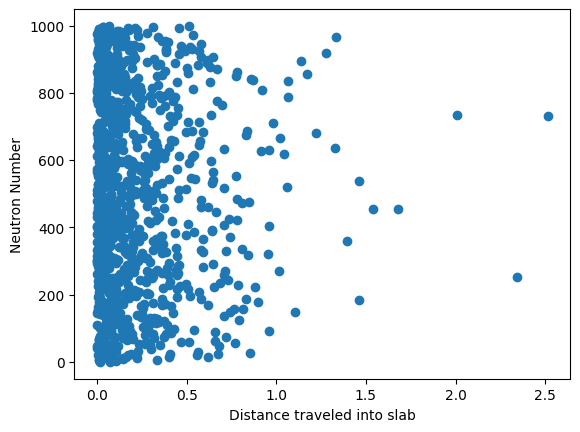

In [6]:
###testthe function with a small number of neutrons
Sigma_t = 2.0
thickness = 3.0
N = 1000
transmission = slab_transmission(Sigma_t, thickness, N, isotropic=True)
print("Out of",N,"neutrons only",int(transmission*N),
      "made it through.\n The fraction that made it through was",
      transmission)

When the neutrons enter the slab at different angles, fewer transmit through the slab without a collision. In this case, none made it through the slab. Also, notice that the scale of the
figure changed because no neutron made it more the 2.5 cm into the slab. We can do the same
convergence study as before by increasing the number of simulated neutrons and looking at
the accuracy of the calculations.


In [7]:
neuts = np.array([2000,4000,8000,16000,32000,64000,128000,256e3,512e3,1024e3,2056e3])
for N in neuts:
    transmission = slab_transmission(Sigma_t, thickness, int(N), isotropic=True)
    print("Out of",N,"neutrons only",int(transmission*N),
          "made it through.\n The fraction that made it through was",
          transmission)

Out of 2000.0 neutrons only 1 made it through.
 The fraction that made it through was 0.0005
Out of 4000.0 neutrons only 0 made it through.
 The fraction that made it through was 0.0
Out of 8000.0 neutrons only 5 made it through.
 The fraction that made it through was 0.000625
Out of 16000.0 neutrons only 8 made it through.
 The fraction that made it through was 0.0005
Out of 32000.0 neutrons only 14 made it through.
 The fraction that made it through was 0.0004375
Out of 64000.0 neutrons only 15 made it through.
 The fraction that made it through was 0.000234375
Out of 128000.0 neutrons only 35 made it through.
 The fraction that made it through was 0.0002734375
Out of 256000.0 neutrons only 76 made it through.
 The fraction that made it through was 0.000296875
Out of 512000.0 neutrons only 166 made it through.
 The fraction that made it through was 0.00032421875
Out of 1024000.0 neutrons only 312 made it through.
 The fraction that made it through was 0.0003046875
Out of 2056000.0 ne

We do start to get to the correct answer, but since so few neutrons get through we have to
simulate a lot of them. Here is the result if we try 10 million:

In [8]:
N = int(1e7)
transmission = slab_transmission(Sigma_t, thickness, N, isotropic=True)
print("Out of",N,"neutrons only",int(transmission*N),
      "made it through.\n The fraction that made it through was",
      transmission)

Out of 10000000 neutrons only 3143 made it through.
 The fraction that made it through was 0.0003143


## 21.6 A First Monte Carlo Shielding Calculation
Both problems that we solved above can be solved pretty easily by hand. To make the
problem more difficult we can add some scattering. We want to know what fraction of the
neutrons get through the slab before being absorbed. This is a typical question in radiation
shielding.

In particular, say that the slab is made up of a material that has $\Sigma_t = 2.0\ \text{cm}^{-1}$,
$\Sigma_s = 0.75\ \text{cm}^{-1}$, and $\Sigma_a = 1.25\ \text{cm}^{-1}$. Also, say that the neutrons are scattered isotropically when
they scatter, that is the direction can change to any other direction upon scattering. This problem cannot be solved very well by diffusion (remember diffusion is an approximation). We can solve it by modifying our procedure from before.

We will need to add the fact that a collision can be a scatter or an absorption. We will 

* still sample a distance to collision using the exponential distribution and the <u> total macroscopic
cross-section </u>, $\Sigma_t = \Sigma_s + \Sigma_a$, as before. 
* The difference is that when the neutron collides, we sample whether it is absorbed or scattered based on the scattering ratio: $\Sigma_s/\Sigma_t$. 
  - If it scatters, we sample another $\mu$ for it and keep following it. 
  - Otherwise, we stop following the neutron because it has been absorbed.


<img src="Uploaded Media/21.6.png" width="300">

The algorithm for this problem just builds on what we did before.

1. Create a counter, $t = 0$ to track the number of neutrons that get through.  
2. Create neutron with $\mu$ sampled from the uniform distribution $\mu \in [0,1]$. Set $x = 0$.  
3. Sample randomly a distance to collision, $l$, from the exponential distribution.  
4. Move the particle to $x = x + l\mu$.  
5. Check to see if $x > 3$. If so $t = t + 1$. Check if $x < 0$, if so go to 2.  
6. Sample a random number $s$ in $[0,1]$, if $s < \Sigma_s/\Sigma_t$, the particle scatters and sample $\mu \in [-1,1]$ and go to step 3. Otherwise, continue.  
7. Go back to 2 until we have run “enough” neutrons.  

In this case we need to check to make sure that the neutron does not exit the slab at $x = 0$.
This is now possible because a scattered neutron can travel backwards toward the face of the
slab. If that happens, to our mind that is the same as absorption because that neutron is not
going to transmit through the slab.

Our algorithm is going to have to change a lot in this case. For each created neutron we
have to follow it until it leaks out of the slab or is absorbed. This could be many collisions
if the scattering ratio is high and $\Sigma_t$ is large. Nevertheless, we can modify the steps of the
simple algorithm to simulate this more complicated scenario.


In [ ]:
def slab_transmission(Sig_s,Sig_a,thickness,N,isotropic=False):
    """Compute the fraction of neutrons that leak through a slab
    Inputs:
        Sig_s: The scattering macroscopic x-section
        Sig_a: The absorption macroscopic x-section
        thickness: Width of the slab
        N: Number of neutrons to simulate
        isotropic: Are the neutrons isotropic or a beam
    Returns:
        transmission: The fraction of neutrons that made it through
    """
    import numpy as np
    import math
    Sig_t = Sig_a + Sig_s
    iSig_t = 1/Sig_t
    transmission = 0.0
    N = int(N)

    for i in range(N):
        
        # source particle direction
        if (isotropic):
            mu = np.random.random()
        else:
            mu = 1.0
        
        # source particle location
        x = 0
        alive = 1
        
        while (alive):
            #get distance to collision
            l = -math.log(1-np.random.random())*iSig_t
            
            #move particle
            x += l*mu
            
            #still in the slab?
            if (x>thickness):
                transmission += 1
                alive = 0
            elif (x<0):
                alive = 0
            else:
                #scatter or absorb
                if (np.random.random() < Sig_s*iSig_t):
                    #scatter, pick new mu
                    mu = np.random.uniform(-1,1)
                else: #absorbed
                    alive = 0
    transmission /= N
    return transmission

As a test, this should do the same thing as the previous example, if we set $\Sigma_s = 0$ and
$\Sigma_a = 2 \ \text{cm}^{-1}$. The scattering ratio in this case is 0 so that all the collisions are absorption, and as
a result, we just need to track distance to collision.

In [11]:
N = 100000
Sigma_s = 0.0
Sigma_a = 2.0
thickness = 3.0
transmission = slab_transmission(Sigma_s,Sigma_a, thickness, N,
                                 isotropic=True)
print("Out of",N,"neutrons only",int(transmission*N),
      "made it through.\n The fraction that made it through was",
      transmission)

Out of 100000 neutrons only 32 made it through.
 The fraction that made it through was 0.00032


That seems to be working in that it is close to the answer we saw before. It would be a good
idea to run this with larger values of $N$ to show we converge to the correct answer. Forgoing
that for now, we will try the problem with $\Sigma_s = 0.75 \ \text{cm}^{-1}$ and $\Sigma_a = 1.25 \ \text{cm}^{-1}$. In this case we would
expect the transmission rate to go up because the total macroscopic cross-section is the same,
but the scattering ratio is greater than zero.

In [12]:
N = 1000000
Sigma_s = 0.75
Sigma_a = 2.0-Sigma_s
thickness = 3.0
transmission = slab_transmission(Sigma_s,Sigma_a, thickness, N,
                                 isotropic=True)
print("Out of",N,"neutrons only",int(transmission*N),
      "made it through.\n The fraction that made it through was",
      transmission)

Out of 1000000 neutrons only 817 made it through.
 The fraction that made it through was 0.000817


In this result we see about a factor of three increase. With scattering it takes much longer to
do the simulation because we might have to follow each neutron for several steps when we
follow it until it is absorbed or leaves the slab. An exercise at the end of the chapter explores
this further.

Slab transmission with scattering is a problem where we cannot write down the answer
easily. As I mentioned, diffusion cannot solve this problem accurately because it is a boundary driven problem with, potentially, a small amount of scattering. To derive the full solution
to the transport equation is beyond the scope of this class, and requires sophisticated mathematics such as singular eigenfunction expansions. It is not a stretch to say in this case
that the Monte Carlo approach is much easier.

## 21.7 Tracking in a Sphere

We would like to be able to track in geometries other than slab geometry. One common geometry is a sphere. We will consider a spherical shell around an isotropic source and compute the number of neutrons that escape through the outer radius. 

We have to be careful because in this geometry a neutron that exits the inner radius will strike the shell on the other side.

<img src="Uploaded Media/21.7.3.png" width="400">

Consider a spherical shell of inner radius, $R_i$, and outer radius $R_o$. Neutrons initially strike
$R_i$ with a direction given by the vector $\Omega = (\theta,\phi)$. 


This coordinate system is shown in the figure below.

<img src="Uploaded Media/21.7.png" width="400">


These directions are defined so that

$$
\Omega \cdot \hat{x} = \sin \theta \cos \phi, \qquad
$$
$$
\Omega \cdot \hat{y} = \sin \theta \sin \phi,
$$

$$
\Omega \cdot \hat{z} = \cos \theta.
$$

The ranges of the angles are $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$ and $\hat{x}, \hat{y}, \hat{z}$ are the unit vectors in the $x$, $y$, and $z$ directions. Using these definitions we know that if a neutron travels a distance $s$ (in direction $\Omega = (\theta,\phi)$), its
position changes by

$$
\Delta x = s \sin \theta \cos \phi, \qquad
$$
$$
\Delta y = s \sin \theta \sin \phi,
$$
$$
\Delta z = s \cos \theta.
$$



One more geometric idiosyncrasy with spherical shells that we have to deal with is the
neutrons that cross the inner radius of the shell. They will strike the inner radius again at the other side of the shell. 


<img src="Uploaded Media/21.7.4.png" width="400">


To find where it will strike the inner radius again we need to find the
value of $s$ such that

$$
(x_i + s \sin \theta \cos \phi)^2 +
(y_i + s \sin \theta \sin \phi)^2 +
(z_i + s \cos \theta)^2
= R_i^2,
$$

where $(x_i, y_i, z_i)$ is the point where the neutron is. We could solve this quadratic equation
for $s$, but this is an opportunity to use a root finding method (such as Ridder’s method) to
find $s$. I will choose a closed root finding method, like Ridder’s method, in this case because
the quadratic could have two solutions and I want to make sure that I get an answer between $s = 0$ and $2R_i$. 

We now have everything we need for our Monte Carlo program. We will create neutrons
initially at $R_i$. Given the symmetry of the sphere we can set $z = R_i$ and $y = x = 0$ initially.
This will mean that the neutrons will have $\theta \in [0,\pi/2]$ initially (otherwise the neutron will
not enter the shell). We then sample a distance to collision, $s$, much like we did before and
follow the neutron around. Now at each step we need to update $x$, $y$, and $z$, and check the
radius that the neutron is at to make sure it is still in the shell.

The code to do this is below.

In [13]:
def ridder(f,a,b,epsilon=1.0e-6):
	"""Find the root of the function f via Ridder's Method where the root lies within [a,b]
	Args:
		f: function to find root of
		a: left-side of interval
		b: right-side of interval
		epsilon: tolerance
	Returns:
		estimate of root
	"""
	assert (b>a)
	assert (f(a)*f(b) < 0)
	delta = b - a
	iterations = 0
	residual = 1.0
	while (np.fabs(residual) > epsilon):
		c = 0.5*(b+a)
		d = 0.0
		if (f(a) - f(b) > 0):
			d = c + (c-a)*f(c)/np.sqrt(f(c)**2-f(a)*f(b))
		else:
			d = c - (c-a)*f(c)/np.sqrt(f(c)**2-f(a)*f(b))
		#now see which part of interval root is in
		if (f(a)*f(d) < 0):
			b=d
		elif (f(b)*f(d) < 0):
			a=d
		residual = f(d)
		iterations += 1
	#print("It took",iterations,"iterations")
	return d #return c

In [ ]:
def shell_transmission(Sig_s,Sig_a,Ri,Ro,N):
    """Compute the fraction of neutrons that leak through a slab
        Inputs:
            Sig_s: The scattering macroscopic x-section
            Sig_a: The absorption macroscopic x-section
            Ri: Inner radius of the shell
            Ro: Outer radius of the shell
            N: Number of neutrons to simulate
        Returns:
            transmission: The fraction of neutrons that made it through
    """
    import numpy as np
    import math
    Sig_t = Sig_a + Sig_s
    iSig_t = 1/Sig_t
    transmission = 0.0
    N = int(N)

    for i in range(N):
        #get initial direction
        theta = np.random.uniform(0,0.5*np.pi)
        phi = np.random.uniform(0,2*np.pi)
        
        #initial position
        r = Ri
        z = Ri
        x = 0
        y = 0


        alive = 1
        
        #vector to keep track of positions
        xvec = x*np.ones([1])
        yvec = y*np.ones([1])
        zvec = z*np.ones([1])
        
        while (alive):
            #get distance to collision
            s = -math.log(1.0-np.random.random())*iSig_t
            
            #move particle
            z += s*math.cos(theta)
            y += s*math.sin(theta)*math.sin(phi)
            x += s*math.sin(theta)*math.cos(phi)
            xvec = np.append(xvec,x)
            yvec = np.append(yvec,y)
            zvec = np.append(zvec,z)

            #distance from the center
            r = math.sqrt(z**2 + y**2 + x**2)

            #still in the shell?
            if (r>Ro): #exit the outer shell
                transmission += 1
                alive = 0
            elif (r<Ri): #exit the inner shell
                #find s so that the neutron is on the other side of the shell
                f = lambda s: ((x + s*math.sin(theta)*math.cos(phi))**2 +
                               (y+s*math.sin(theta)*math.sin(phi))**2 +
                               (z + s*math.cos(theta))**2 - Ri**2)
                s = ridder(f,1e-10,2*Ri,1.0e-10)
                
                #move neutron to the other side of the inner shell
                z += s*math.cos(theta)
                y += s*math.sin(theta)*math.sin(phi)
                x += s*math.sin(theta)*math.cos(phi)
                r = Ri
                #check that we are on the inner radius
                assert(math.fabs(x**2+y**2+z**2 - Ri**2) < 1e-6)
            else: #inside the shell
                #scatter or absorb
                if (np.random.random() < Sig_s*iSig_t):
                    #scatter, pick new angles
                    theta = np.random.uniform(0,math.pi)
                    phi = np.random.uniform(0,2*math.pi)
                else: #absorbed
                    alive = 0
    transmission /= N
    return transmission

We will simulate transmission through a shell of thickness 3 cm and inner radius 2 cm. Also, we will visualize the tracks that the neutrons take through the shell.

In [15]:
N = 100
Sigma_s = 1.0
Sigma_a = 1.0
Ri = 2
Ro = Ri + 3
transmission = shell_transmission(Sigma_s,Sigma_a,Ri,Ro,N)
print("Out of",N,"neutrons only",int(transmission*N),
      "made it through.\n The fraction that made it through was",
      transmission)

Out of 100 neutrons only 1 made it through.
 The fraction that made it through was 0.01


Notice that all the neutrons start at $z = R_i$ and $x = y = 0$ as prescribed in the code. We
can also see the fact that when a neutron re-enters the hollow center, it streams across to the
other side. This figure is also a way to check that the streaming through the hollow part of
the shell is handled correctly: we should not see any neutron tracks end in the hollow part of
the sphere (though this is hard to tell with a 2-D projection of the sphere). We can also see the
one neutron that escaped the sphere.


<img src="Uploaded Media/21.7.2.png" width="400">


Upon increasing the number of neutrons, we expect to get a more accurate answer, though
we have not said what that answer is. With $N = 10^5$ we get

In [16]:
N = 100000
Sigma_s = 1.0
Sigma_a = 1.0
Ri = 2
Ro = Ri + 3
transmission = shell_transmission(Sigma_s,Sigma_a,Ri,Ro,N)
print("Out of",N,"neutrons only",int(transmission*N),
      "made it through.\n The fraction that made it through was",
      transmission)

Out of 100000 neutrons only 627 made it through.
 The fraction that made it through was 0.00627


## 21.8 A Real Shielding Problem

We will now take a large step forward. We will try to solve the problem of designing a
lead-208 shield for a bare reactor made of uranium-235. We will use the full energy dependent
cross-sections for lead and the actual fission spectrum of U-235. To do this we will have to
read in the data for the lead microscopic cross-sections and the fission spectrum. We covered
how to do this in Section 5.1. Using that knowledge we can read in a csv file of the format:

incident neutron energy, cross-section in barns ($10^{-24}\ \text{cm}^2$).

The code below does this. A plot of the cross-sections follows.


In [2]:
import csv
import numpy as np
lead_s = [] #create a blank list for the x-sects
lead_s_energy = [] #create a blank list for the x-sects energies
#this loop will only execute if the file opens
with open("pb_scat.csv") as csvfile:
    pbScat = csv.reader(csvfile)
    for row in pbScat: #have for loop that loops over each line
        lead_s.append(float(row[1]))
        lead_s_energy.append(float(row[0]))
lead_scattering = np.array([lead_s_energy,lead_s])

lead_abs = [] #create a blank list for the x-sects
lead_abs_energy = [] #create a blank list for the x-sects energies
    #this loop will only execute if the file opens
with open("pb_radcap.csv") as csvfile:
    pbAbs = csv.reader(csvfile)
    for row in pbAbs: #have for loop that loops over each line
        lead_abs.append(float(row[1]))
        lead_abs_energy.append(float(row[0]))
lead_absorption = np.array([lead_abs_energy,lead_abs])

<img src="Uploaded Media/21.8.1.png">

For the fission spectrum we will use the Watt fission spectrum. This spectrum is the relative
likelihood of a fission neutron being born with energy $E$. The fission spectrum is typically
denoted as $\chi(E)$ and given by

$$
\chi(E) = 0.453 e^{-1.036E} \sinh\!\left(\sqrt{2.29E}\right),
$$

with $E$ given in MeV.

<img src="Uploaded Media/21.8.2.png">

To solve this problem we will have to change our algorithm somewhat. Firstly, we will
have to generate neutrons with energies sampled from the fission spectrum and then evaluate
the cross-sections at the neutron’s energy. Secondly, we will have to change how we scatter
particles. When a particle scatters we will have to sample a new energy for the post-scattered
neutron. We will tackle each of these next.

## 21.9 Rejection Sampling

Previously, we discussed how to sample from a distribution by inverting the CDF and then
using a random number between 0 and 1 to give us the inverse CDF value corresponding to
our sample. With the fission spectrum we cannot do this easily. We do not have a CDF, we
just have a distribution that gives a relative likelihood of a fission neutron being born with a
certain energy. To sample from this we use rejection sampling. The idea of rejection sampling
is to draw a box around the PDF of the distribution we want to sample from, and pick points
in the box. If the point is below the curve, we accept the point, otherwise we reject it and
sample again. The effect of this is that we will get more points where the PDF is large, and
few points where the PDF is small.

We will demonstrate the idea of rejection sampling with our fission spectrum data. To do
this we find the maximum and the minimum of the function over the energy range from the
minimum energy in the lead scattering table to 10 MeV. This allows us to define the box, and
we randomly pick points in the box. Then we check to see if a point is above or below the
function.

<img src="Uploaded Media/21.9.1.png">

The histogram of the accepted samples should look like the fission spectrum we wanted
to sample. The histogram will not be perfect because we have a finite number of samples.

<img src="Uploaded Media/21.9.2.png">

## 21.10 Looking up Energies
To look up the cross-section for lead at different energies we need a function that can return the value of the cross-section for a given energy. We can make this happen by finding the
energy in the data set that is closest to the input energy. This can be done using the NumPy
function `argmin`. This function returns the index of a NumPy array with the smallest value.
Therefore, we pass to `argmin` the difference between a target energy and the vector of energies in the table. In effect for a given neutron energy this will give the point in the table closest
to that energy. We define such an energy lookup function below.


In [18]:
def energy_lookup(data_set, inp_energy):
    """look up energy in a data set and return the nearest energy in the table
        Input:
            data_set: a vector of energies
            inp_energy: the energy to lookup
        Output:
            index: the index of the nearest neighbor in the table
    """
    #argmin returns the indices of the smallest members of an array
    #here we’ll look for the minimum difference
    #between the input energy and the table
    index = np.argmin(np.fabs(data_set-inp_energy))
    return index

## 21.11 Elastic Scattering
When a particle scatters elastically, the energy of the scattered neutron, $E'$, of a neutron
with an initial energy $E$ is governed by a probability given by

$$
P(E \to E') =
\begin{cases}
\frac{1}{E(1-\alpha)} & \alpha E \le E' \le E \\
0 & \text{otherwise},
\end{cases}
$$

where

$$
\alpha = \frac{(A - 1)^2}{(A + 1)^2},
$$

with $A$ the mass of the nucleus. Therefore, we can sample the value of the scattered neutron’s
energy from a uniform distribution from $\alpha E$ to $E$. The neutron’s angle would also be a function of the scattered energy, in order to preserve momentum. For simplicity we will say that
the neutron’s angle after the scatter is isotropic, though this is not completely correct. The
proper scattering would give a particular value of $\mu$ for a given energy change.


## 21.12 Lead Shielding of Reactor Algorithm and Code

The algorithm will be an enhanced version of the one before that concerned neutrons striking an absorbing and scattering slab. We will assume isotropic, elastic scattering and radiative
capture as the only reactions in the lead, though this simplification could be modified using
the additional cross-sections for inelastic scattering, (n,2n) reactions, etc. The algorithm now
looks like:

1. Create a neutron with $\mu$ sampled from the uniform distribution $\mu \in [0,1]$ and an energy
sampled from the fission spectrum via rejection sampling. Set $x = 0$.  
2. Sample randomly a distance to collision, $l$, from the exponential distribution.  
3. Move the particle to $x = x + l\mu$.  
4. Check to see if $x$ is greater than the shield thickness, if so stop following the neutron. Check
if $x < 0$, if so go to 1.  
5. Sample a random number $s$ in $[0,1]$, if $s < \Sigma_s/\Sigma_t$, the particle scatters and sample $\mu \in [-1,1]$ and an energy based on the formula above and go to step 3. Otherwise, continue.  
6. Go back to 1 until we have run “enough” neutrons.  

The resulting function is given below.

In [ ]:
def expfiss(x):
    return 0.453*np.exp(-1.036*x)*np.sinh(np.sqrt(2.29*x))

def slab_reactor(sig_s,sig_a,thickness,density,A,N,isotropic=False):
    """Compute the fraction of neutrons that leak through a slab
        Inputs:
            sig_s: The scattering microscopic x-section array in form Energy,X-sect
            sig_a: The absorption microscopic x-section
            thickness: Width of the slab
            density: density of material in atoms per cc
            A: atomic weight of shield
            N: Number of neutrons to simulate
            isotropic: Are the neutrons isotropic or a beam
        Returns:
            transmission: energies of neutrons that leak through
            created: energies of neutrons that were born
    """
    import numpy as np
    import math
    import random
    alpha = (A-1.0)**2/(A+1.0)**2
    Sig_s = sig_s.copy()
    Sig_a = sig_a.copy()
    Sig_s[1,:] = density/1e24*Sig_s[1,:]
    Sig_a[1,:] = density/1e24*Sig_a[1,:]
    #make rejection box
    min_eng = np.min([np.min(Sig_s[0,:]),np.min(Sig_a[0,:])])
    max_eng = np.max([np.max(Sig_s[0,:]),np.max(Sig_a[0,:])])
    max_prob = np.max([np.max(expfiss(Sig_a[0,:]/1000000.)),np.max(expfiss(Sig_s[0,:]/1000000.))])
    # max_prob = 0.5
    transmission = []
    created = []
    N = int(N)
    for i in range(N):
        #sample direction
        if (isotropic):
            mu = np.random.random()
        else:
            mu = 1.0
        #compute energy via rejection sampling
        rejected = 1
        while (rejected):
            #pick x
            x = np.random.uniform(min_eng,max_eng)
            y = np.random.uniform(0,max_prob)
            rel_prob = expfiss(x/1000000.)
            if (y <= rel_prob):
                energy = x
                rejected = 0
        
        #initial position is 0
        x = 0
        created.append(energy)
        alive = 1
        while (alive):
            #get distance to collision
            scat_index = energy_lookup(Sig_s[0,:],energy)
            abs_index = energy_lookup(Sig_a[0,:],energy)
            cur_scat = Sig_s[1,scat_index]
            cur_abs = Sig_a[1,abs_index]
            Sig_t = cur_scat + cur_abs
            l = -math.log(1-np.random.random())/Sig_t
            #move particle
            x += l*mu
            
            #still in the slab
            if (x>thickness):
                transmission.append(energy)
                alive = 0
            elif (x<0):
                alive = 0
            else:
                #scatter or absorb
                if (random.random() < cur_scat/Sig_t):
                    #scatter, pick new mu and energy
                    mu = np.random.uniform(-1,1)
                    energy = np.random.uniform(alpha*energy,energy)
                else: #absorbed
                    alive = 0
    return transmission, created

This algorithm will be more time consuming to run because tracking each neutron now
requires more work (e.g., we have to perform rejection sampling to get an initial energy), and
the fact that the scattering ratio for lead appears to be high from the figure above. We will run
the algorithm with only one million neutrons. Before running the code, we need to compute
the number density for lead-208 because the algorithm takes the microscopic cross-section as
an input and multiplies that by a number density to get the macroscopic cross-section.



In [29]:
import math
N = 1e4
density = 11.34/208*6.022e23
thickness = 150
transmission,created = slab_reactor(lead_scattering,lead_absorption,thickness,density,208,N,isotropic=True)

The output of the function is an array of the transmitted particle energies and the initial energies. The distribution of the transmitted energies is

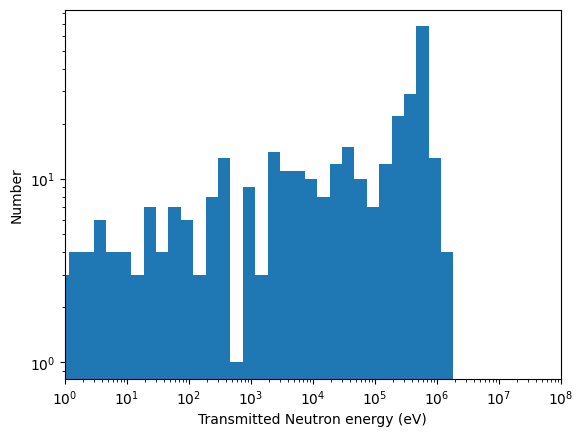

In [30]:
import matplotlib.pyplot as plt
bins = np.logspace(np.log10(min(transmission)), np.log10(max(transmission)), num=100)
plt.hist(transmission, bins=bins, log=True)
plt.xscale('log')
plt.xlim(1,100000000)
plt.yscale('log')
plt.xlabel("Transmitted Neutron energy (eV)")
plt.ylabel("Number")
plt.show()

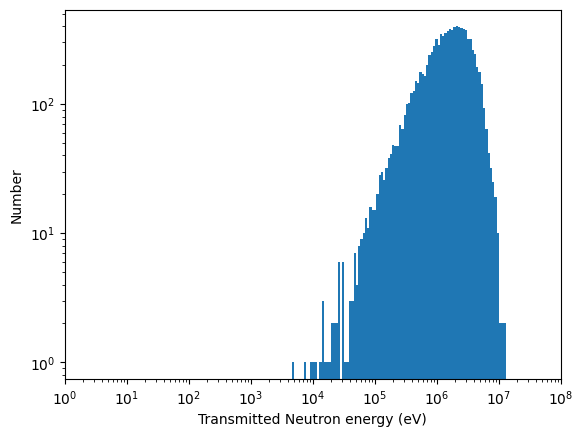

In [31]:
import matplotlib.pyplot as plt
bins = np.logspace(np.log10(min(created)), np.log10(max(created)), num=100)
plt.hist(created, bins=bins, log=True)
plt.xscale('log')
plt.xlim(1,100000000)
plt.yscale('log')
plt.xlabel("Transmitted Neutron energy (eV)")
plt.ylabel("Number")
plt.show()